# Variable Dictionary: Hypertension Prediction Model

## Complete Variable Reference Table

| Variable | Type | Measurement | Clinical Importance for Hypertension |
|----------|------|-------------|--------------------------------------|
| **ID** | Integer | Unique ID | ❌ **Exclude from model** - No clinical relevance; identifier only |
| **DBP** | Numeric | mmHg | Direct diagnostic criterion (DBP ≥ 90 mmHg = hypertension); indicates peripheral vascular resistance |
| **SBP** | Numeric | mmHg | Direct diagnostic criterion (SBP ≥ 140 mmHg = hypertension); stronger CVD predictor than DBP |
| **BMI** | Numeric | kg/m² | Primary modifiable risk factor; obesity increases blood volume, cardiac workload, and insulin resistance |
| **age** | Numeric | Years | Strongest non-modifiable risk factor; arterial stiffness increases with age |
| **married** | Binary | 0=No, 1=Yes | Proxy for psychosocial support; married patients often have lower stress and better medication adherence |
| **male.gender** | Binary | 0=Female, 1=Male | Men develop HTN earlier; women protected by estrogen until menopause |
| **hgb_centered** | Numeric | g/dL (centered) | Anemia forces heart to pump harder (↑cardiac output), affecting BP dynamics |
| **adv_HIV** | Binary | 0=No, 1=Yes | Advanced HIV causes chronic inflammation and endothelial dysfunction → arterial stiffness |
| **survtime** | Numeric | Time units | Helps distinguish prevalent vs. incident hypertension; temporal context |
| **event** | Binary | 0=Censored, 1=Event | Hypertension leads to adverse events (CVD, death); represents downstream consequences |
| **arv_naive** | Binary | 0=On ARV, 1=Naive | Uncontrolled HIV (naive) drives inflammation; some ARVs cause metabolic side effects |
| **urban.clinic** | Binary | 0=Rural, 1=Urban | Social determinant: urban = higher stress/processed foods but better healthcare access |
| **log_creat_centered** | Numeric | Log(mg/dL) centered | Kidney function marker; bidirectional relationship with HTN (kidney disease ↔ hypertension) |
| **IPW_weight** | Numeric | Statistical weight | ❌ **Exclude from model** - Statistical adjustment tool, not biological predictor |
| **SBP_ge120** | Binary | 0=<120, 1=≥120 | "Elevated" BP (pre-hypertension); precursor category at high risk of progression |
| **hypertension** | Binary | 0=No, 1=Yes | ✅ **TARGET VARIABLE** - Clinical outcome (SBP ≥140 OR DBP ≥90) requiring intervention |

---

## Variable Categories Quick Reference

| Category | Variables | Use in ML Model |
|----------|-----------|-----------------|
| **Target Variable** | hypertension | ✅ Output/Prediction |
| **Direct BP Measures** | SBP, DBP, SBP_ge120 | ✅ Predictors (or derive target) |
| **Clinical Risk Factors** | age, BMI, log_creat_centered | ✅ Strong predictors |
| **HIV-Specific Factors** | adv_HIV, arv_naive, hgb_centered | ✅ Important predictors |
| **Demographics/Social** | male.gender, married, urban.clinic | ✅ Predictors |
| **Study Design** | event, survtime | ⚠️ Use with caution (temporal leakage) |
| **Administrative** | ID, IPW_weight | ❌ **DO NOT USE** |


# 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
from sklearn.inspection import PartialDependenceDisplay
import time
import warnings
from sklearn.model_selection import train_test_split,RandomizedSearchCV,StratifiedKFold,learning_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, f1_score, auc,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
                             precision_recall_curve)
import xgboost as xgb
 #fix all randomness for full reproducibility
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

# 2. DATA IMPORTATION

In [2]:
df = pd.read_csv('htn_dat.csv')

In [3]:
df.head(10)

,ID,DBP,SBP,BMI,age,married,male.gender,hgb_centered,adv_HIV,survtime,event,arv_naive,urban.clinic,log_creat_centered,IPW_weight,SBP_ge120
0,16097,60,90,NaN,28.000000,0.0,0,NaN,NaN,338,1,1,0,NaN,0.924379,0
1,930,75,110,27.339912,26.458590,1.0,0,-3.9,0.0,439,1,1,1,5.421770e-02,1.163862,0
2,6877,60,80,17.689789,42.951405,0.0,0,-3.2,NaN,752,1,1,0,-3.597409e-01,0.721148,0
3,36464,60,90,19.854080,50.149212,1.0,1,NaN,NaN,526,1,1,1,NaN,0.829452,0
4,36180,60,100,21.295294,30.554415,0.0,1,-0.4,NaN,215,1,1,0,-1.000000e-07,0.856046,0
5,7923,60,120,16.880194,20.372347,1.0,0,-4.0,NaN,272,1,1,0,3.344296e-01,1.164691,0
6,30408,59,100,22.038567,28.793976,0.0,0,NaN,NaN,1669,1,1,1,NaN,1.211947,0
7,40375,60,100,21.580042,49.152634,0.0,1,0.8,NaN,388,1,0,0,-2.231437e-01,0.667708,0
8,34243,70,120,19.067711,29.705681,1.0,0,-1.0,NaN,14,1,1,0,-1.337490e-02,1.016784,0
9,7355,58,110,26.058353,28.208077,1.0,0,NaN,NaN,419,1,1,0,NaN,1.077339,0


In [4]:
# Create hypertension as a target variable
df['hypertension'] = ((df['SBP'] >= 140) | (df['DBP'] >= 90)).astype(int)
# Hypertension is defined as SBP >= 140 OR DBP >= 90

In [5]:
df.head(10)

,ID,DBP,SBP,BMI,age,married,male.gender,hgb_centered,adv_HIV,survtime,event,arv_naive,urban.clinic,log_creat_centered,IPW_weight,SBP_ge120,hypertension
0,16097,60,90,NaN,28.000000,0.0,0,NaN,NaN,338,1,1,0,NaN,0.924379,0,0
1,930,75,110,27.339912,26.458590,1.0,0,-3.9,0.0,439,1,1,1,5.421770e-02,1.163862,0,0
2,6877,60,80,17.689789,42.951405,0.0,0,-3.2,NaN,752,1,1,0,-3.597409e-01,0.721148,0,0
3,36464,60,90,19.854080,50.149212,1.0,1,NaN,NaN,526,1,1,1,NaN,0.829452,0,0
4,36180,60,100,21.295294,30.554415,0.0,1,-0.4,NaN,215,1,1,0,-1.000000e-07,0.856046,0,0
5,7923,60,120,16.880194,20.372347,1.0,0,-4.0,NaN,272,1,1,0,3.344296e-01,1.164691,0,0
6,30408,59,100,22.038567,28.793976,0.0,0,NaN,NaN,1669,1,1,1,NaN,1.211947,0,0
7,40375,60,100,21.580042,49.152634,0.0,1,0.8,NaN,388,1,0,0,-2.231437e-01,0.667708,0,0
8,34243,70,120,19.067711,29.705681,1.0,0,-1.0,NaN,14,1,1,0,-1.337490e-02,1.016784,0,0
9,7355,58,110,26.058353,28.208077,1.0,0,NaN,NaN,419,1,1,0,NaN,1.077339,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  4999 non-null   int64  
 1   DBP                 4999 non-null   int64  
 2   SBP                 4999 non-null   int64  
 3   BMI                 4329 non-null   float64
 4   age                 4999 non-null   float64
 5   married             4835 non-null   float64
 6   male.gender         4999 non-null   int64  
 7   hgb_centered        3605 non-null   float64
 8   adv_HIV             3038 non-null   float64
 9   survtime            4999 non-null   int64  
 10  event               4999 non-null   int64  
 11  arv_naive           4999 non-null   int64  
 12  urban.clinic        4999 non-null   int64  
 13  log_creat_centered  3461 non-null   float64
 14  IPW_weight          4999 non-null   float64
 15  SBP_ge120           4999 non-null   int64  
 16  hypertension     

# 3. DATA PREPROCESSING

In [7]:
duplicated = df[df.duplicated()]
print('number of rows duplicated:',duplicated.shape)

number of rows duplicated: (0, 17)


In [8]:
df.isnull().sum()

ID                       0
DBP                      0
SBP                      0
BMI                    670
age                      0
married                164
male.gender              0
hgb_centered          1394
adv_HIV               1961
survtime                 0
event                    0
arv_naive                0
urban.clinic             0
log_creat_centered    1538
IPW_weight               0
SBP_ge120                0
hypertension             0
dtype: int64

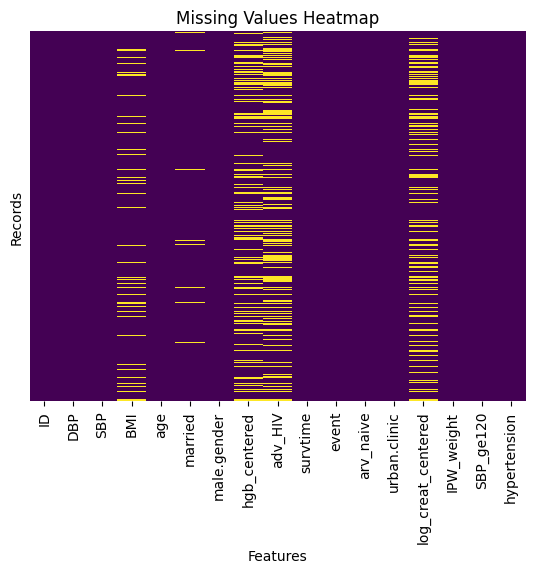

In [9]:
## Missing values Heatmap
plt.figure()
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Missing Values Heatmap')
plt.xlabel('Features')
plt.ylabel('Records')
plt.show()

In [10]:
num_imputer = SimpleImputer(strategy = 'median')
cat_imputer = SimpleImputer(strategy = 'most_frequent')

num_features = ['BMI','hgb_centered','log_creat_centered']
cat_features = ['married','adv_HIV',]

df[num_features] = num_imputer.fit_transform(df[num_features])
df[cat_features] = cat_imputer.fit_transform(df[cat_features])

df.isnull().sum()

ID                    0
DBP                   0
SBP                   0
BMI                   0
age                   0
married               0
male.gender           0
hgb_centered          0
adv_HIV               0
survtime              0
event                 0
arv_naive             0
urban.clinic          0
log_creat_centered    0
IPW_weight            0
SBP_ge120             0
hypertension          0
dtype: int64

In [11]:
## scale the data
num_cols = [
    'DBP',
    'SBP',
    'BMI',
    'age',
    'hgb_centered',
    'survtime',
    'log_creat_centered',
    'IPW_weight'
]


In [12]:
df.isnull().sum()

ID                    0
DBP                   0
SBP                   0
BMI                   0
age                   0
married               0
male.gender           0
hgb_centered          0
adv_HIV               0
survtime              0
event                 0
arv_naive             0
urban.clinic          0
log_creat_centered    0
IPW_weight            0
SBP_ge120             0
hypertension          0
dtype: int64

In [13]:
print(df[num_cols].describe())

               DBP          SBP          BMI          age  hgb_centered  \
count  4999.000000  4999.000000  4999.000000  4999.000000   4999.000000   
mean     68.030206   110.593919    21.349213    35.191304     -0.011392   
std      10.319607    14.776308     3.374456    10.563761      2.201053   
min      40.000000    65.000000    15.002075    16.024641    -10.600000   
25%      60.000000   100.000000    19.241324    27.197809     -0.900000   
50%      70.000000   110.000000    20.835959    33.470226      0.100000   
75%      73.000000   120.000000    22.837370    41.582478      1.000000   
max     120.000000   210.000000    39.437584    79.630386     35.200001   

          survtime  log_creat_centered   IPW_weight  
count  4999.000000         4999.000000  4999.000000  
mean    750.529506           -0.092267     0.995007  
std     650.878636            0.262685     0.325378  
min       0.000000           -1.825464     0.521930  
25%     178.500000           -0.197319     0.839650  


In [14]:
#apply the scaler- This transforms numeric features to have a mean zero and a std of 0

In [15]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    'DBP',
    'SBP',
    'BMI',
    'age',
    'hgb_centered',
    'survtime',
    'log_creat_centered',
    'IPW_weight'
]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [16]:
print(df[num_cols].describe())

                DBP           SBP           BMI           age  hgb_centered  \
count  4.999000e+03  4.999000e+03  4.999000e+03  4.999000e+03  4.999000e+03   
mean  -3.638707e-16  1.819353e-16  3.979835e-16  5.372778e-16 -2.842739e-18   
std    1.000100e+00  1.000100e+00  1.000100e+00  1.000100e+00  1.000100e+00   
min   -2.716480e+00 -3.085918e+00 -1.881125e+00 -1.814560e+00 -4.811182e+00   
25%   -7.782282e-01 -7.170248e-01 -6.247228e-01 -7.567660e-01 -4.037596e-01   
50%    1.908979e-01 -4.019801e-02 -1.521152e-01 -1.629392e-01  5.061382e-02   
75%    4.816357e-01  6.366287e-01  4.410506e-01  6.050698e-01  4.595497e-01   
max    5.036528e+00  6.728070e+00  5.360918e+00  4.207169e+00  1.599912e+01   

           survtime  log_creat_centered    IPW_weight  
count  4.999000e+03        4.999000e+03  4.999000e+03  
mean   9.096766e-17        3.269150e-17 -4.633665e-16  
std    1.000100e+00        1.000100e+00  1.000100e+00  
min   -1.153217e+00       -6.598663e+00 -1.454074e+00  
25%   -8

In [17]:
corr = df.corr()['hypertension']

In [18]:
corr

ID                    0.313155
DBP                   0.438204
SBP                   0.545887
BMI                   0.111307
age                   0.146042
married               0.033557
male.gender           0.055858
hgb_centered          0.100374
adv_HIV              -0.019335
survtime              0.006044
event                -0.044931
arv_naive            -0.024296
urban.clinic          0.042919
log_creat_centered    0.045215
IPW_weight           -0.016448
SBP_ge120             0.788751
hypertension          1.000000
Name: hypertension, dtype: float64

In [19]:
corr.sort_values(ascending=False)

hypertension          1.000000
SBP_ge120             0.788751
SBP                   0.545887
DBP                   0.438204
ID                    0.313155
age                   0.146042
BMI                   0.111307
hgb_centered          0.100374
male.gender           0.055858
log_creat_centered    0.045215
urban.clinic          0.042919
married               0.033557
survtime              0.006044
IPW_weight           -0.016448
adv_HIV              -0.019335
arv_naive            -0.024296
event                -0.044931
Name: hypertension, dtype: float64

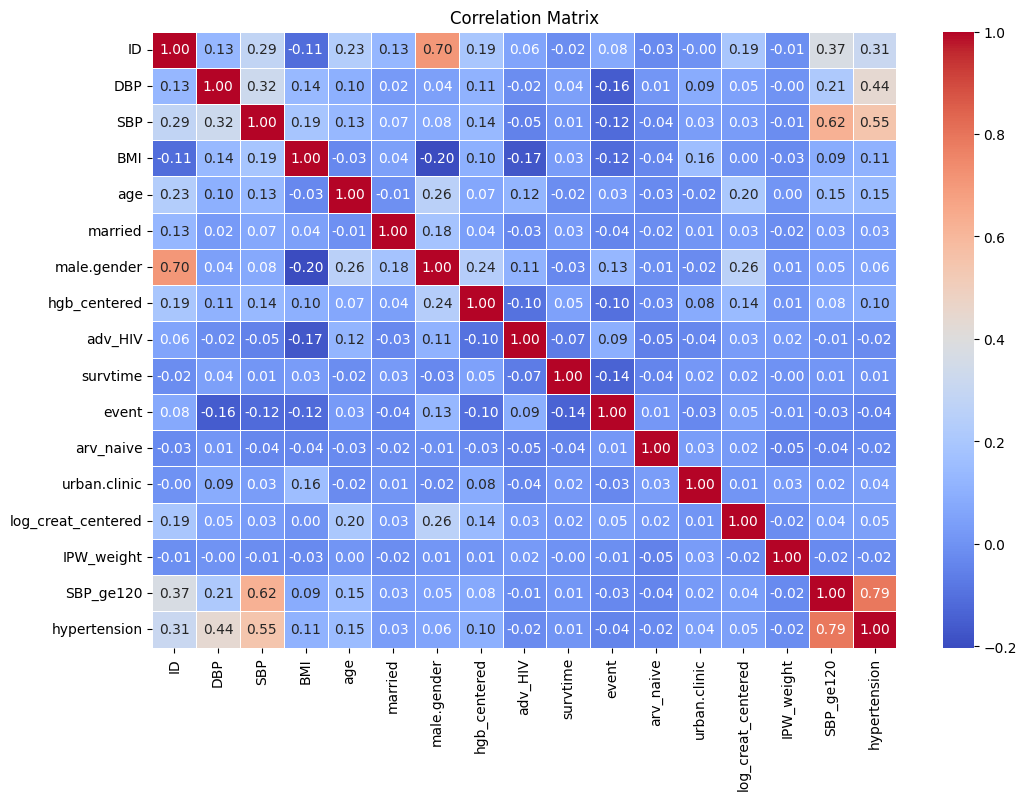

In [20]:
## Correlation matrix

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

## Target variable distribution

In [21]:
df['hypertension'].value_counts(normalize=True) * 100

hypertension
0    92.19844
1     7.80156
Name: proportion, dtype: float64

In [22]:
target_dist = df['hypertension'].value_counts().to_frame()
target_dist.columns = ['Count']
target_dist['Percentage'] = (target_dist['Count'] / target_dist['Count'].sum()) * 100
target_dist

,Count,Percentage
hypertension,,
0,4609,92.19844
1,390,7.80156


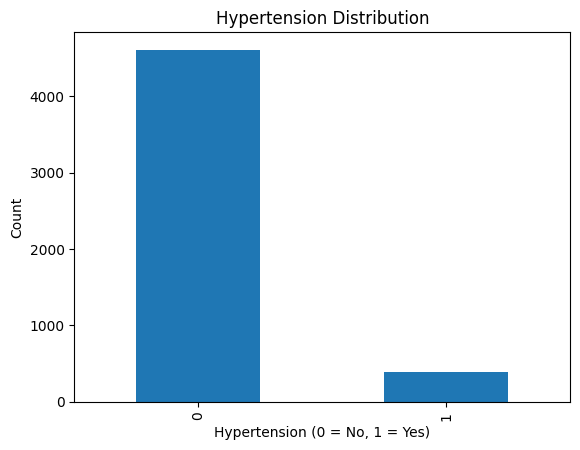

In [23]:
import matplotlib.pyplot as plt

df['hypertension'].value_counts().plot(kind='bar')
plt.title('Hypertension Distribution')
plt.xlabel('Hypertension (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

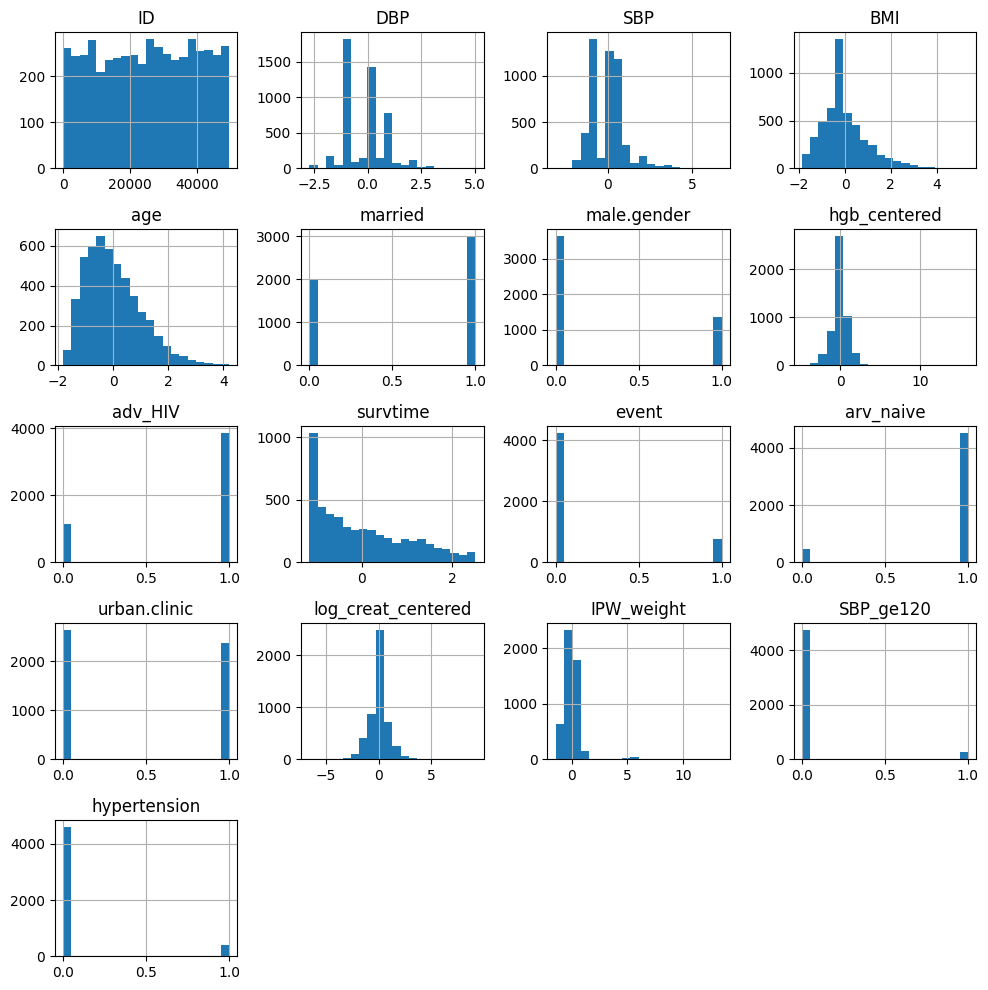

In [24]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
df[num_cols].hist(figsize=(10, 10), bins=20)
plt.title('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.savefig("output_image.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
X = df.drop(columns= ['DBP','SBP','ID','IPW_weight','SBP_ge120','hypertension'])
y = df['hypertension']

In [26]:
X.head()

,BMI,age,married,male.gender,hgb_centered,adv_HIV,survtime,event,arv_naive,urban.clinic,log_creat_centered
0,-0.152115,-0.680820,0.0,0,0.050614,1.0,-0.633867,1,1,0,-0.015557
1,1.775486,-0.826750,1.0,0,-1.766880,0.0,-0.478677,1,1,1,0.557701
2,-1.084557,0.734670,0.0,0,-1.448819,1.0,0.002259,1,1,0,-1.018331
3,-0.443118,1.416106,1.0,1,0.050614,1.0,-0.344998,1,1,1,-0.015557
4,-0.015980,-0.438987,0.0,1,-0.176573,1.0,-0.822862,1,1,0,0.351282


In [27]:
X.isnull().sum()

BMI                   0
age                   0
married               0
male.gender           0
hgb_centered          0
adv_HIV               0
survtime              0
event                 0
arv_naive             0
urban.clinic          0
log_creat_centered    0
dtype: int64

In [28]:
y.head(20)

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
Name: hypertension, dtype: int64

# 4. DATA PARTITIONING

In [29]:
## Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   ##Same class ratio in train and test and Prevents biased evaluation

)

In [30]:
y_train.value_counts()

hypertension
0    3687
1     312
Name: count, dtype: int64

In [31]:
#!pip install imblearn

In [32]:
#!pip uninstall imbalanced-learn -y
#!pip uninstall scikit-learn -y




In [33]:
#!pip install scikit-learn==1.5.2
#!pip install imbalanced-learn==0.12.4

In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

## Train models

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [36]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            max_iter=1000
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=7,
            weights="distance"
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=1.0,
            kernel="rbf",
            probability=True
        ))
    ]),

    "Naive Bayes": GaussianNB(var_smoothing=1e-9),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train_res, y_train_res,
    test_size=0.2,
    random_state=42,
    stratify=y_train_res
)

## TRAIN AND EVALUATE ALL MODELS

In [38]:
results = []

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Some models need probability for AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    
    # Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    })

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
6,XGBoost,0.886780,0.865385,0.915875,0.889914,0.956936
1,KNN,0.863729,0.795806,0.978290,0.877663,0.952900
5,Random Forest,0.842712,0.806804,0.900950,0.851282,0.927226
2,SVM,0.817627,0.786765,0.871099,0.826787,0.879965
4,Decision Tree,0.712542,0.676437,0.814111,0.738916,0.769888
3,Naive Bayes,0.651525,0.614125,0.814111,0.700117,0.716762
0,Logistic Regression,0.649492,0.641753,0.675712,0.658295,0.720810


### Confusion Matrices for all models

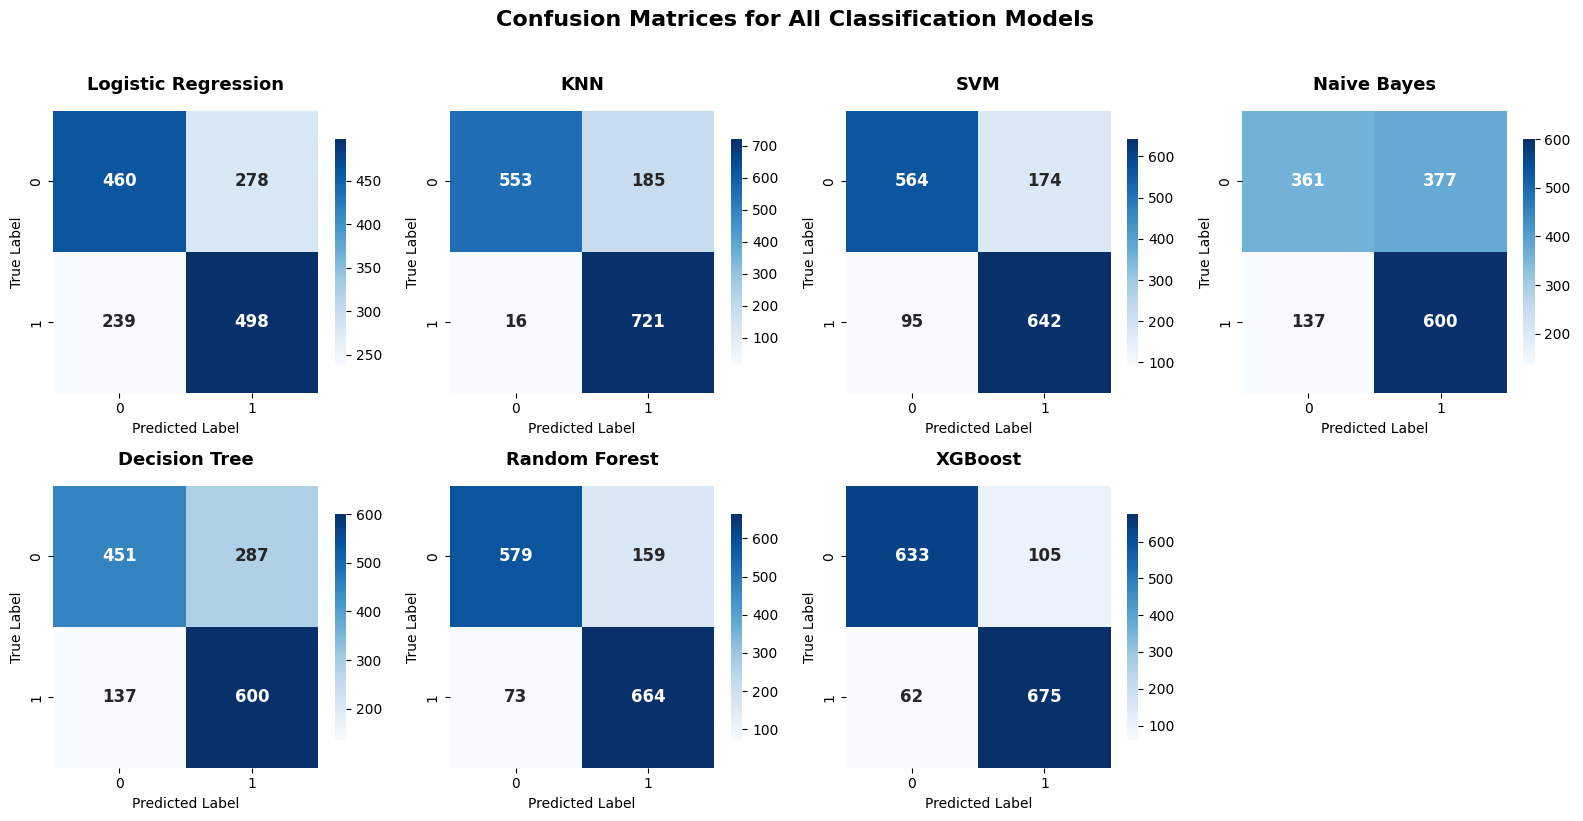

In [39]:
y_pred_dict = {}
for name, model in models.items():
    y_pred_dict[name] = model.predict(X_test)  # Generate predictions for each model

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

model_names = list(models.keys())

for idx, (name, y_pred) in enumerate(y_pred_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar_kws={'shrink': 0.8}, ax=axes[idx],
                annot_kws={'size': 12, 'weight': 'bold'})
    
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold', pad=15)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xticklabels(['0', '1'], fontsize=10)
    axes[idx].set_yticklabels(['0', '1'], fontsize=10)

# Hide the last unused subplot
axes[-1].axis('off')

plt.suptitle('Confusion Matrices for All Classification Models', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### ROC-AUC Curves for all models

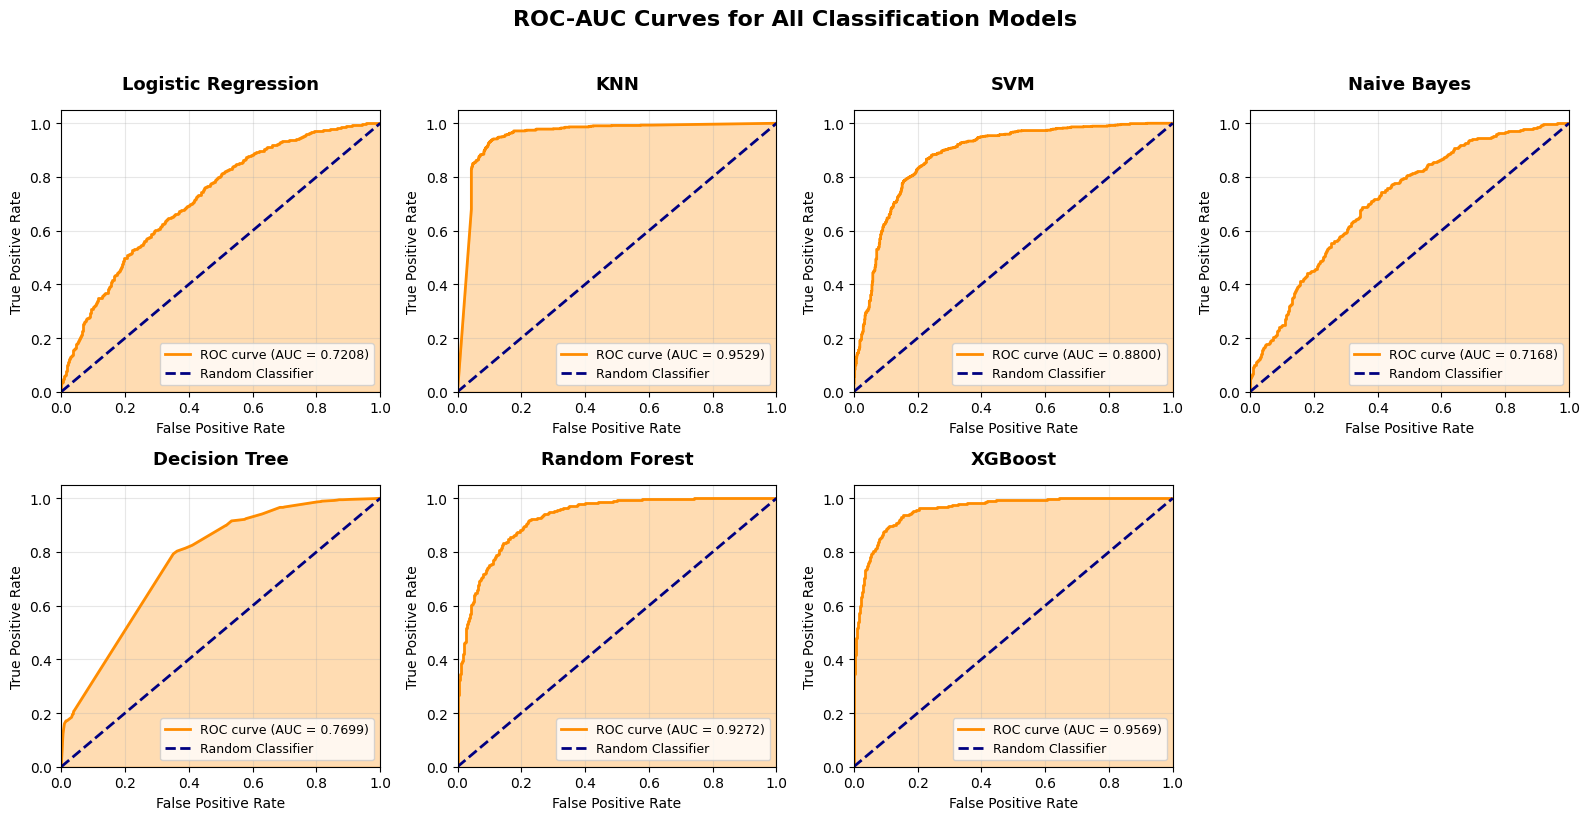

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Create probability predictions dictionary for ROC curves
y_proba_dict = {}
for name, model in models.items():
    try:
        # Use predict_proba for probability predictions (needed for ROC curves)
        y_proba_dict[name] = model.predict_proba(X_test)[:, 1]  # Get probabilities for positive class
    except AttributeError:
        # Some models might not have predict_proba method
        y_proba_dict[name] = None
    
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (name, y_proba) in enumerate(y_proba_dict.items()):
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)  # Now roc_curve is properly imported
        roc_auc = auc(fpr, tpr)  # Now auc is properly imported
        
        axes[idx].plot(fpr, tpr, color='darkorange', lw=2, 
                      label=f'ROC curve (AUC = {roc_auc:.4f})')
        axes[idx].plot([0, 1], [0, 1], color='navy', lw=2, 
                      linestyle='--', label='Random Classifier')
        axes[idx].fill_between(fpr, tpr, alpha=0.3, color='darkorange')
        
        axes[idx].set_xlim([0.0, 1.0])
        axes[idx].set_ylim([0.0, 1.05])
        axes[idx].set_xlabel('False Positive Rate', fontsize=10)
        axes[idx].set_ylabel('True Positive Rate', fontsize=10)
        axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold', pad=15)
        axes[idx].legend(loc="lower right", fontsize=9)
        axes[idx].grid(alpha=0.3)

# Hide the last unused subplot
axes[-1].axis('off')

plt.suptitle('ROC-AUC Curves for All Classification Models', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Classification reports for all models

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance

print("="*100)
print("DETAILED CLASSIFICATION REPORTS FOR ALL MODELS")
print("="*100)

for name, model in models.items():
    y_pred = y_pred_dict[name]
    
    print(f"\n{'='*100}")
    print(f"📊 {name.upper()}")
    print(f"{'='*100}")
    print(classification_report(y_test, y_pred, 
                                target_names=['No Hypertension (0)', 'Hypertension (1)'],
                                digits=4))
with open('classification_reports.txt', 'w') as f:
    f.write("="*100 + "\n")
    f.write("CLASSIFICATION REPORTS - ALL MODELS\n")
    f.write("="*100 + "\n\n")
    
    for name, model in models.items():
        y_pred = y_pred_dict[name]
        f.write(f"\n{'='*100}\n")
        f.write(f"{name.upper()}\n")
        f.write(f"{'='*100}\n")
        f.write(classification_report(y_test, y_pred, 
                                      target_names=['No Hypertension (0)', 'Hypertension (1)'],
                                      digits=4))
        f.write("\n")

DETAILED CLASSIFICATION REPORTS FOR ALL MODELS

📊 LOGISTIC REGRESSION
                     precision    recall  f1-score   support

No Hypertension (0)     0.6581    0.6233    0.6402       738
   Hypertension (1)     0.6418    0.6757    0.6583       737

           accuracy                         0.6495      1475
          macro avg     0.6499    0.6495    0.6493      1475
       weighted avg     0.6499    0.6495    0.6493      1475


📊 KNN
                     precision    recall  f1-score   support

No Hypertension (0)     0.9719    0.7493    0.8462       738
   Hypertension (1)     0.7958    0.9783    0.8777       737

           accuracy                         0.8637      1475
          macro avg     0.8838    0.8638    0.8619      1475
       weighted avg     0.8839    0.8637    0.8619      1475


📊 SVM
                     precision    recall  f1-score   support

No Hypertension (0)     0.8558    0.7642    0.8074       738
   Hypertension (1)     0.7868    0.8711    0.8268     

### Feature importance

In [42]:
print("\n" + "="*100)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*100)

# Get feature names
feature_names = X_train_res.columns.tolist()

# Dictionary to store feature importances
feature_importance_dict = {}

# --- Logistic Regression ---
print("\n🔹 Extracting Logistic Regression coefficients...")
try:
    lr_model = models["Logistic Regression"].named_steps["model"]
    lr_coef = lr_model.coef_[0]
    feature_importance_dict["Logistic Regression"] = {
        'features': feature_names,
        'importance': np.abs(lr_coef),  # Use absolute values
        'coefficients': lr_coef
    }
    print("   ✅ Done")
except Exception as e:
    print(f"   ⚠️ Error: {e}")

# --- Decision Tree ---
print("🔹 Extracting Decision Tree feature importance...")
try:
    dt_model = models["Decision Tree"]
    dt_importance = dt_model.feature_importances_
    feature_importance_dict["Decision Tree"] = {
        'features': feature_names,
        'importance': dt_importance
    }
    print("   ✅ Done")
except Exception as e:
    print(f"   ⚠️ Error: {e}")

# --- Random Forest ---
print("🔹 Extracting Random Forest feature importance...")
try:
    rf_model = models["Random Forest"]
    rf_importance = rf_model.feature_importances_
    feature_importance_dict["Random Forest"] = {
        'features': feature_names,
        'importance': rf_importance
    }
    print("   ✅ Done")
except Exception as e:
    print(f"   ⚠️ Error: {e}")

# --- XGBoost ---
print("🔹 Extracting XGBoost feature importance...")
try:
    xgb_model = models["XGBoost"]
    xgb_importance = xgb_model.feature_importances_
    feature_importance_dict["XGBoost"] = {
        'features': feature_names,
        'importance': xgb_importance
    }
    print("   ✅ Done")
except Exception as e:
    print(f"   ⚠️ Error: {e}")

# --- SVM (using coefficients if available) ---
print("🔹 Extracting SVM coefficients...")
try:
    svm_model = models["SVM"].named_steps["model"]
    if hasattr(svm_model, 'coef_'):
        svm_coef = svm_model.coef_[0]
        feature_importance_dict["SVM"] = {
            'features': feature_names,
            'importance': np.abs(svm_coef),
            'coefficients': svm_coef
        }
        print("   ✅ Done")
    else:
        print("   ⚠️ SVM coefficients not available")
except Exception as e:
    print(f"   ⚠️ Error: {e}")


FEATURE IMPORTANCE ANALYSIS

🔹 Extracting Logistic Regression coefficients...
   ✅ Done
🔹 Extracting Decision Tree feature importance...
   ✅ Done
🔹 Extracting Random Forest feature importance...
   ✅ Done
🔹 Extracting XGBoost feature importance...
   ✅ Done
🔹 Extracting SVM coefficients...
   ⚠️ SVM coefficients not available



📊 Generating Feature Importance Visualizations...


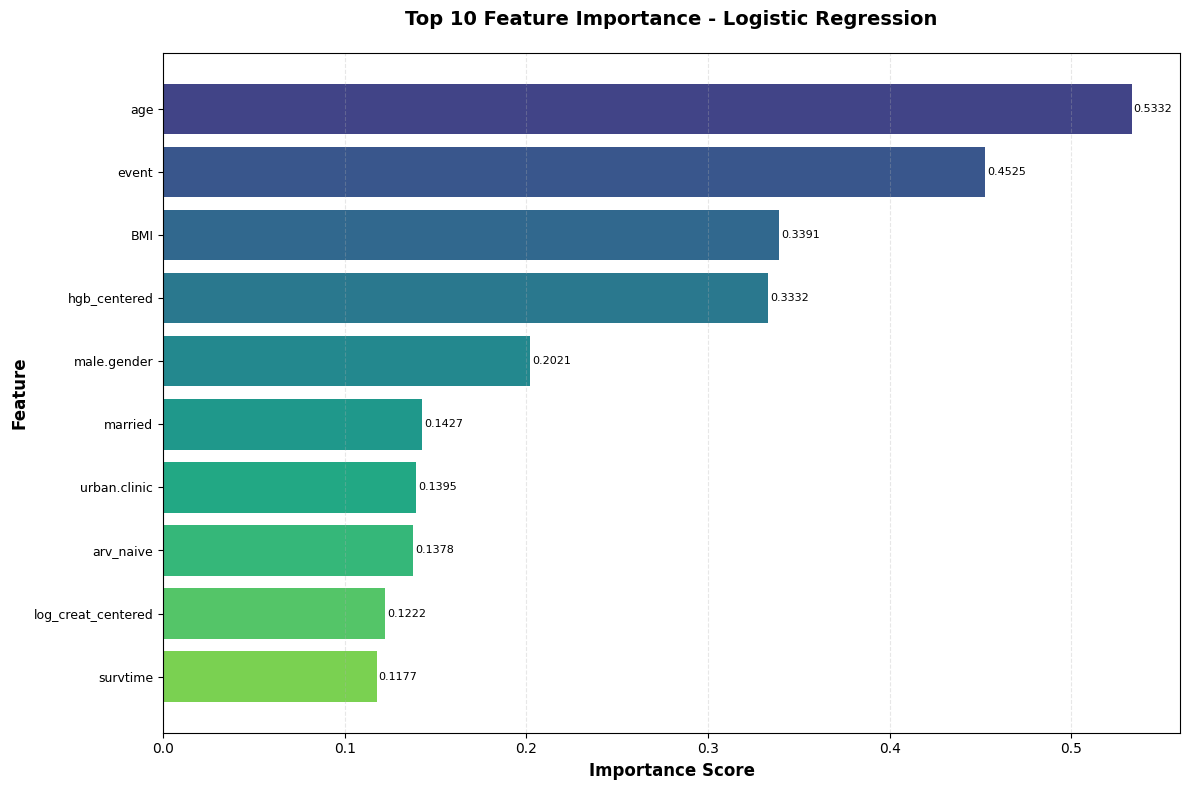


📋 TOP 10 FEATURES - LOGISTIC REGRESSION
Rank  Feature                                 Importance
------------------------------------------------------------
1     age                                       0.533161
2     event                                     0.452476
3     BMI                                       0.339116
4     hgb_centered                              0.333188
5     male.gender                               0.202066
6     married                                   0.142658
7     urban.clinic                              0.139506
8     arv_naive                                 0.137840
9     log_creat_centered                        0.122204
10    survtime                                  0.117734


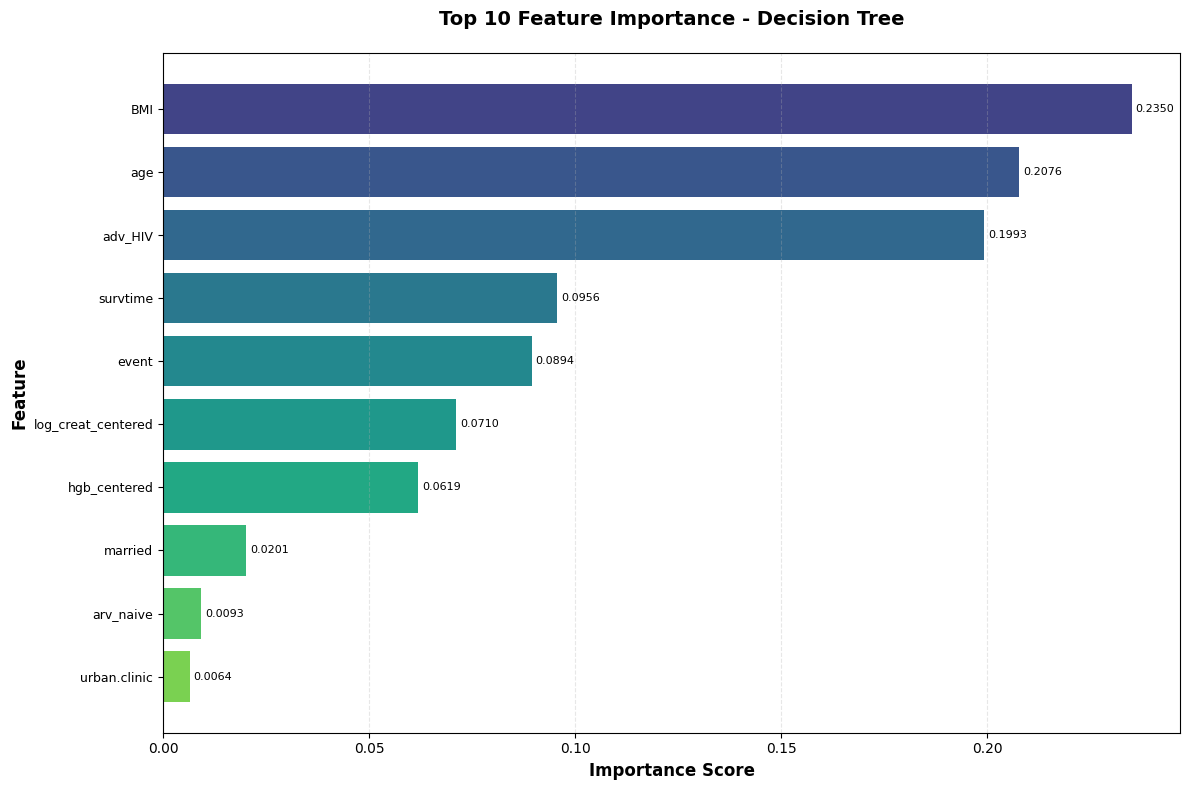


📋 TOP 10 FEATURES - DECISION TREE
Rank  Feature                                 Importance
------------------------------------------------------------
1     BMI                                       0.234954
2     age                                       0.207607
3     adv_HIV                                   0.199268
4     survtime                                  0.095573
5     event                                     0.089397
6     log_creat_centered                        0.070980
7     hgb_centered                              0.061880
8     married                                   0.020134
9     arv_naive                                 0.009323
10    urban.clinic                              0.006440


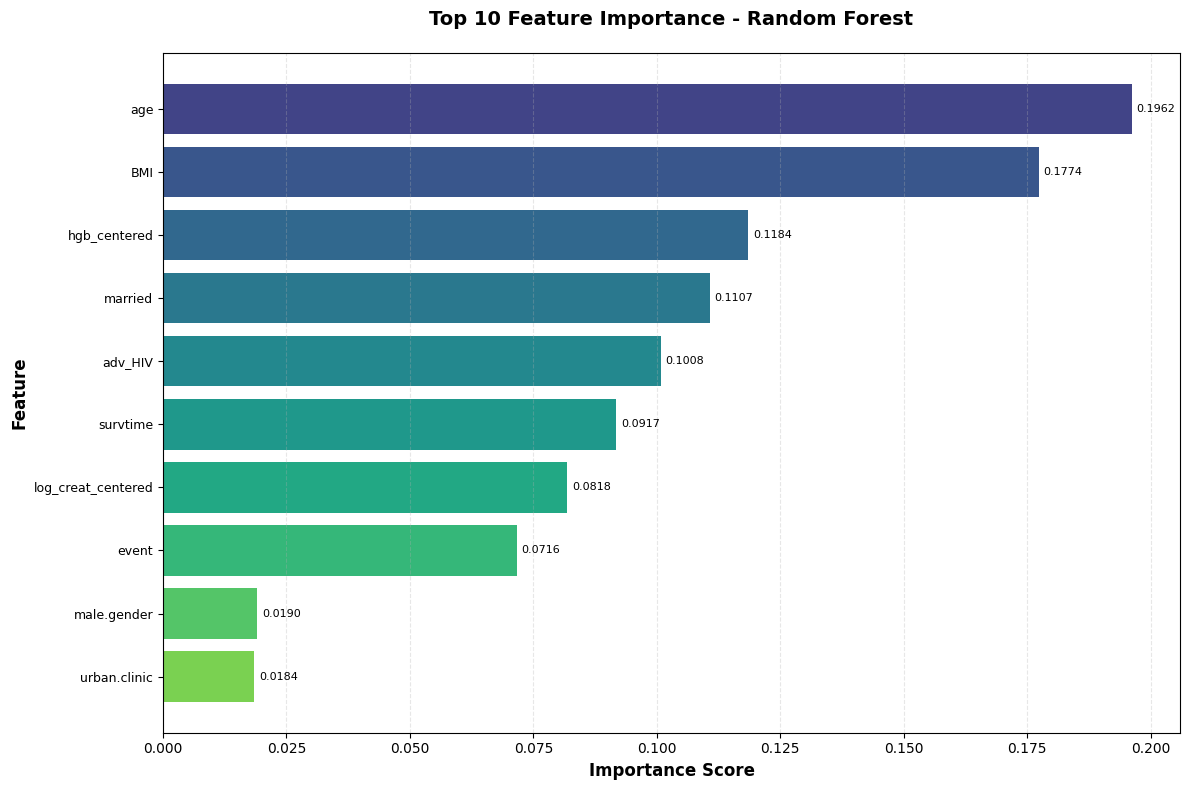


📋 TOP 10 FEATURES - RANDOM FOREST
Rank  Feature                                 Importance
------------------------------------------------------------
1     age                                       0.196157
2     BMI                                       0.177368
3     hgb_centered                              0.118445
4     married                                   0.110709
5     adv_HIV                                   0.100776
6     survtime                                  0.091745
7     log_creat_centered                        0.081840
8     event                                     0.071603
9     male.gender                               0.019040
10    urban.clinic                              0.018446


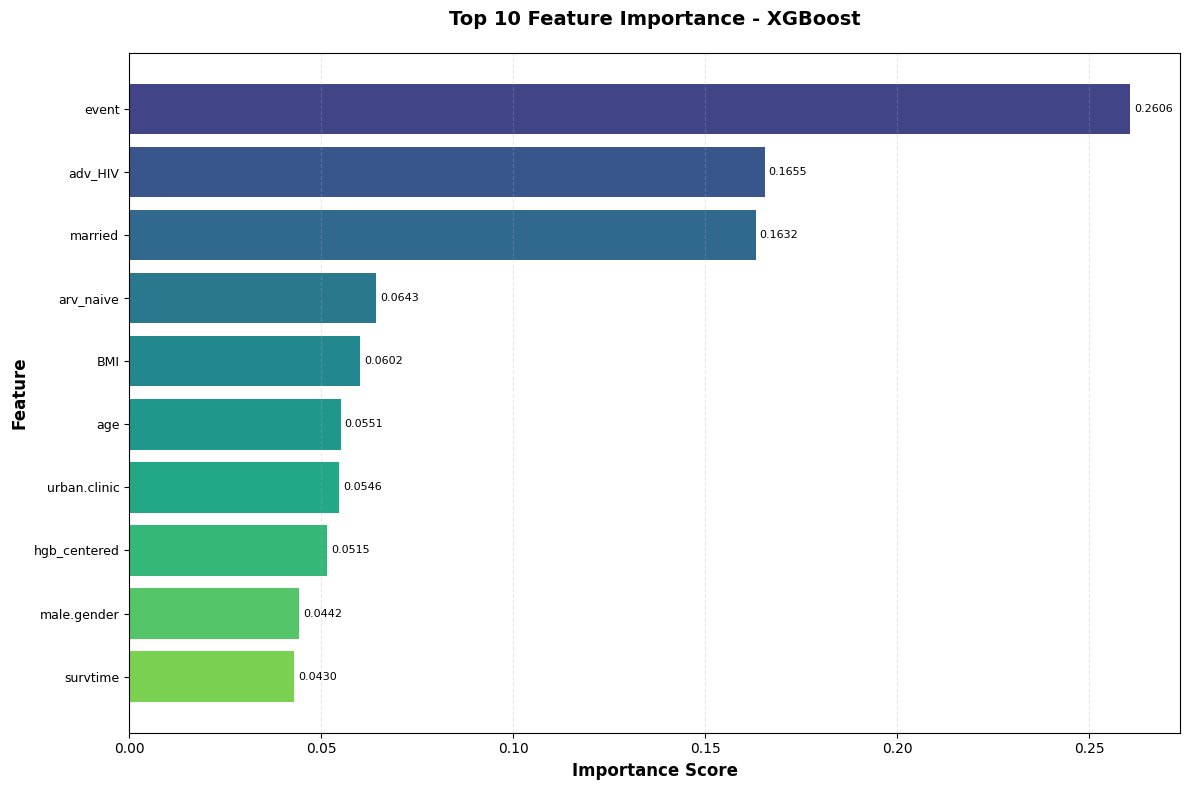


📋 TOP 10 FEATURES - XGBOOST
Rank  Feature                                 Importance
------------------------------------------------------------
1     event                                     0.260606
2     adv_HIV                                   0.165456
3     married                                   0.163176
4     arv_naive                                 0.064291
5     BMI                                       0.060229
6     age                                       0.055051
7     urban.clinic                              0.054624
8     hgb_centered                              0.051524
9     male.gender                               0.044206
10    survtime                                  0.042969


In [43]:
print("\n📊 Generating Feature Importance Visualizations...")

n_top_features = 10  # Show top 15 features

for model_name, importance_data in feature_importance_dict.items():
    features = importance_data['features']
    importances = importance_data['importance']
    
    # Get top N features
    indices = np.argsort(importances)[-n_top_features:][::-1]
    top_features = [features[i] for i in indices]
    top_importances = importances[indices]
    
    # Create figure
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_features)))
    
    bars = plt.barh(range(len(top_features)), top_importances, color=colors)
    plt.gca().invert_yaxis()  # Highest at top
    
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
    plt.ylabel('Feature', fontsize=12, fontweight='bold')
    plt.title(f'Top {n_top_features} Feature Importance - {model_name}', 
              fontsize=14, fontweight='bold', pad=20)
    plt.yticks(range(len(top_features)), top_features, fontsize=9)
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_importances)):
        plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print top 10 features
    print(f"\n{'='*80}")
    print(f"📋 TOP 10 FEATURES - {model_name.upper()}")
    print(f"{'='*80}")
    print(f"{'Rank':<6}{'Feature':<35}{'Importance':>15}")
    print("-"*60)
    for rank, (feat, imp) in enumerate(zip(top_features[:10], top_importances[:10]), 1):
        print(f"{rank:<6}{feat:<35}{imp:>15.6f}")

🎯 IDENTIFYING TOP 3 PREDICTORS - XGBOOST (BEST MODEL)

📊 Calculating permutation importance...



🏆 TOP 3 PREDICTORS OF HYPERTENSION

Rank  Feature                              Importance     Std Dev  Relative %
------------------------------------------------------------------------------------------
1     hgb_centered                           0.100000    0.003716      17.90%
2     age                                    0.085085    0.008288      15.23%
3     BMI                                    0.074780    0.007427      13.39%


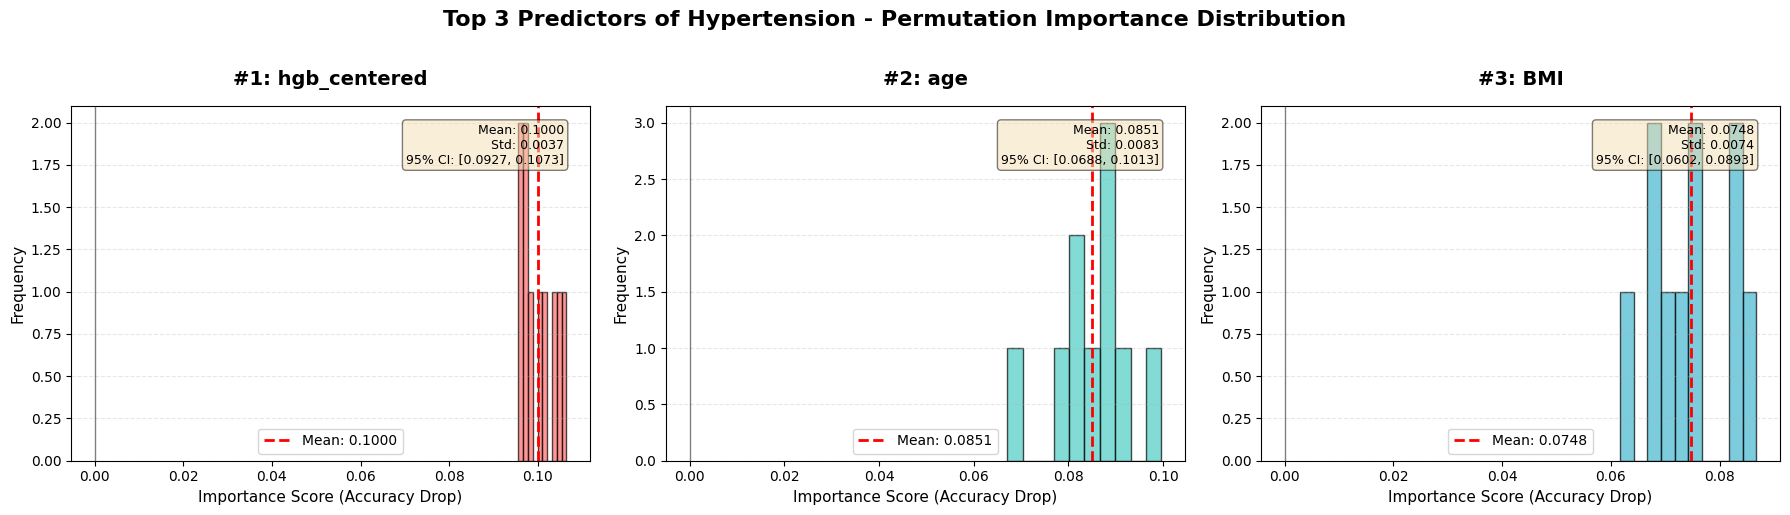

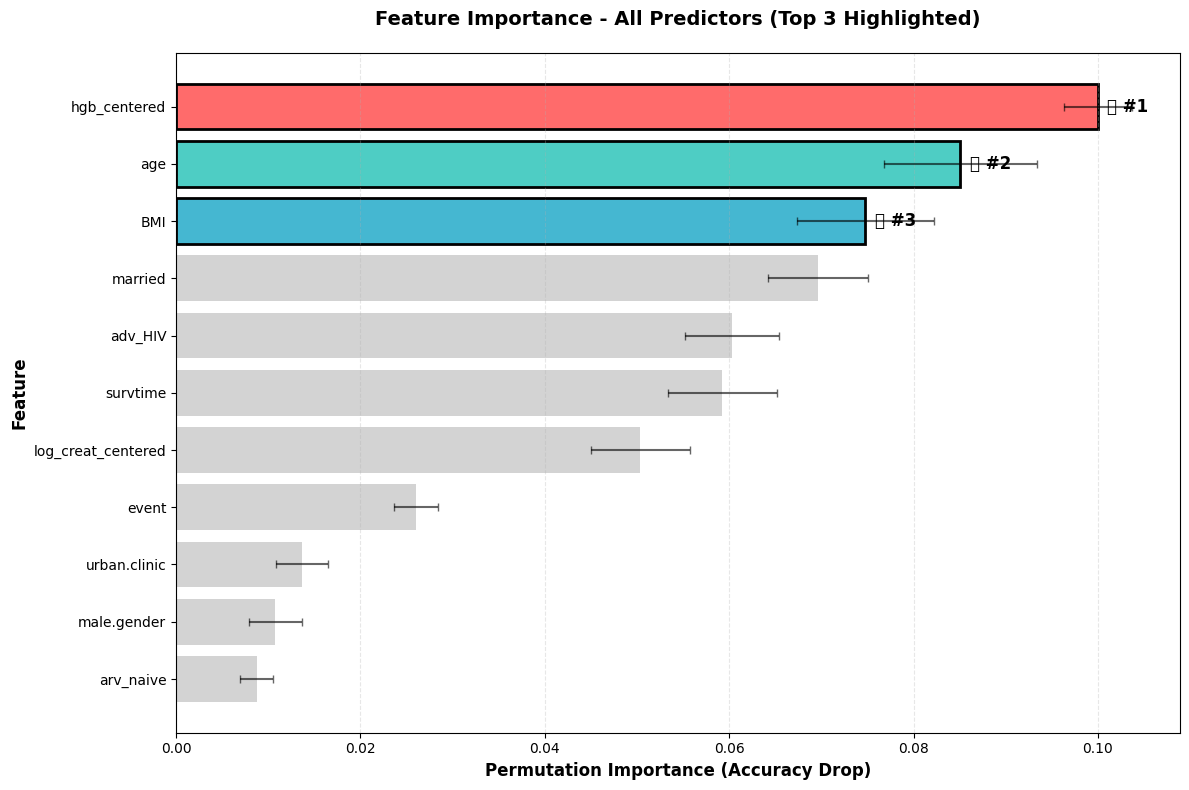


📋 DETAILED ANALYSIS OF TOP 3 PREDICTORS

#1: HGB_CENTERED
  Importance Score:     0.100000
  Standard Deviation:   0.003716
  95% Confidence Interval: [0.092716, 0.107284]
  Relative Importance:  17.90% of total

  Statistical Summary:
    Mean:     0.1377
    Median:   0.0506
    Std Dev:  1.0273
    Min:      -4.6294
    Max:      15.9991
    Skewness: 1.8705

#2: AGE
  Importance Score:     0.085085
  Standard Deviation:   0.008288
  95% Confidence Interval: [0.068840, 0.101329]
  Relative Importance:  15.23% of total

  Statistical Summary:
    Mean:     0.2180
    Median:   0.0734
    Std Dev:  1.0606
    Min:      -1.8146
    Max:      4.2072
    Skewness: 0.6695

#3: BMI
  Importance Score:     0.074780
  Standard Deviation:   0.007427
  95% Confidence Interval: [0.060223, 0.089337]
  Relative Importance:  13.39% of total

  Statistical Summary:
    Mean:     0.1598
    Median:   -0.1340
    Std Dev:  1.0135
    Min:      -1.8811
    Max:      5.3609
    Skewness: 1.2228

✅ RES

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

print("="*100)
print("🎯 IDENTIFYING TOP 3 PREDICTORS - XGBOOST (BEST MODEL)")
print("="*100)

# Get feature names
feature_names = X_train_res.columns.tolist()

# ============================================================================
# 1. PERMUTATION IMPORTANCE FOR XGBOOST
# ============================================================================
print("\n📊 Calculating permutation importance...")

xgb_model = models["XGBoost"]
perm_importance = permutation_importance(
    xgb_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Get importance scores
importance_mean = perm_importance.importances_mean
importance_std = perm_importance.importances_std

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_mean,
    'Std_Dev': importance_std
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# ============================================================================
# 2. DISPLAY TOP 3 PREDICTORS
# ============================================================================
top_3 = importance_df.head(3)

print("\n" + "="*100)
print("🏆 TOP 3 PREDICTORS OF HYPERTENSION")
print("="*100)
print(f"\n{'Rank':<6}{'Feature':<35}{'Importance':>12}{'Std Dev':>12}{'Relative %':>12}")
print("-"*90)

total_importance = importance_df['Importance'].sum()

for rank, row in top_3.iterrows():
    relative_pct = (row['Importance'] / total_importance) * 100
    print(f"{rank+1:<6}{row['Feature']:<35}{row['Importance']:>12.6f}{row['Std_Dev']:>12.6f}{relative_pct:>11.2f}%")

print("="*100)
# ============================================================================
# 3. VISUALIZATION - TOP 3 PREDICTORS (Publication Quality)
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Colors for top 3
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Red, Teal, Blue

for idx, (row, color) in enumerate(zip(top_3.itertuples(), colors)):
    # Get all importance values for this feature across repeats
    feat_idx = feature_names.index(row.Feature)
    
    # ✅ FIX: Changed 'importances_' to 'importances' (no trailing underscore)
    all_repeats = perm_importance.importances[feat_idx]
    
    # Plot distribution
    axes[idx].hist(all_repeats, bins=10, color=color, alpha=0.7, edgecolor='black')
    axes[idx].axvline(row.Importance, color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {row.Importance:.4f}')
    axes[idx].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    axes[idx].set_title(f'#{idx+1}: {row.Feature}', fontsize=14, fontweight='bold', pad=15)
    axes[idx].set_xlabel('Importance Score (Accuracy Drop)', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add statistics
    stats_text = f'Mean: {row.Importance:.4f}\nStd: {row.Std_Dev:.4f}\n95% CI: [{row.Importance - 1.96*row.Std_Dev:.4f}, {row.Importance + 1.96*row.Std_Dev:.4f}]'
    axes[idx].text(0.95, 0.95, stats_text, transform=axes[idx].transAxes, 
                   fontsize=9, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Top 3 Predictors of Hypertension - Permutation Importance Distribution', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# ============================================================================
# 4. COMPARISON BAR CHART - ALL FEATURES (Highlight Top 3)
# ============================================================================
plt.figure(figsize=(12, 8))

# Create bars for all features
all_indices = np.arange(len(importance_df))
bars = plt.barh(all_indices, importance_df['Importance'], color='lightgray')

# Highlight top 3
for i in range(3):
    bars[i].set_color(colors[i])
    bars[i].set_edgecolor('black')
    bars[i].set_linewidth(2)

# Add error bars
plt.errorbar(importance_df['Importance'], all_indices, 
             xerr=importance_df['Std_Dev'], 
             fmt='none', color='black', capsize=3, alpha=0.6)

plt.gca().invert_yaxis()
plt.xlabel('Permutation Importance (Accuracy Drop)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Feature Importance - All Predictors (Top 3 Highlighted)', 
          fontsize=14, fontweight='bold', pad=20)
plt.yticks(all_indices, importance_df['Feature'], fontsize=10)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add rank labels
for i in range(3):
    plt.text(importance_df.iloc[i]['Importance'] + 0.001, i, 
             f'🥇 #{i+1}', fontsize=12, fontweight='bold', 
             verticalalignment='center')

plt.tight_layout()
plt.show()

# ============================================================================
# 5. DETAILED ANALYSIS OF TOP 3
# ============================================================================
print("\n" + "="*100)
print("📋 DETAILED ANALYSIS OF TOP 3 PREDICTORS")
print("="*100)

for rank, row in top_3.iterrows():
    feat_idx = feature_names.index(row.Feature)
    feat_values = X_train_res[row.Feature]
    
    print(f"\n{'='*100}")
    print(f"#{rank+1}: {row.Feature.upper()}")
    print(f"{'='*100}")
    print(f"  Importance Score:     {row.Importance:.6f}")
    print(f"  Standard Deviation:   {row.Std_Dev:.6f}")
    print(f"  95% Confidence Interval: [{row.Importance - 1.96*row.Std_Dev:.6f}, {row.Importance + 1.96*row.Std_Dev:.6f}]")
    print(f"  Relative Importance:  {(row.Importance / total_importance) * 100:.2f}% of total")
    print(f"\n  Statistical Summary:")
    print(f"    Mean:     {feat_values.mean():.4f}")
    print(f"    Median:   {feat_values.median():.4f}")
    print(f"    Std Dev:  {feat_values.std():.4f}")
    print(f"    Min:      {feat_values.min():.4f}")
    print(f"    Max:      {feat_values.max():.4f}")
    print(f"    Skewness: {feat_values.skew():.4f}")

# ============================================================================
# 6. SAVE RESULTS
# ============================================================================
importance_df.to_csv('feature_importance_xgboost.csv', index=False)
top_3.to_csv('top_3_predictors.csv', index=False)

print("\n" + "="*100)
print("✅ RESULTS SAVED")
print("="*100)
print("  • 'feature_importance_xgboost.csv' - All features ranked")
print("  • 'top_3_predictors.csv' - Top 3 predictors only")

# ============================================================================
# 7. THESIS-READY SUMMARY
# ============================================================================
print("\n" + "="*100)
print("📝 THESIS-READY SUMMARY")
print("="*100)

print(f"\nPermutation importance analysis of the XGBoost model identified the following")
print(f"as the top three predictors of hypertension:")
print(f"\n1. **{top_3.iloc[0]['Feature']}** (Importance = {top_3.iloc[0]['Importance']:.4f} ± {top_3.iloc[0]['Std_Dev']:.4f})")
print(f"2. **{top_3.iloc[1]['Feature']}** (Importance = {top_3.iloc[1]['Importance']:.4f} ± {top_3.iloc[1]['Std_Dev']:.4f})")
print(f"3. **{top_3.iloc[2]['Feature']}** (Importance = {top_3.iloc[2]['Importance']:.4f} ± {top_3.iloc[2]['Std_Dev']:.4f})")

print(f"\nThese three features collectively account for ")
print(f"{(top_3['Importance'].sum() / total_importance) * 100:.2f}% of the model's total predictive importance,")
print(f"indicating their critical role in hypertension classification.")

print("\n" + "="*100)

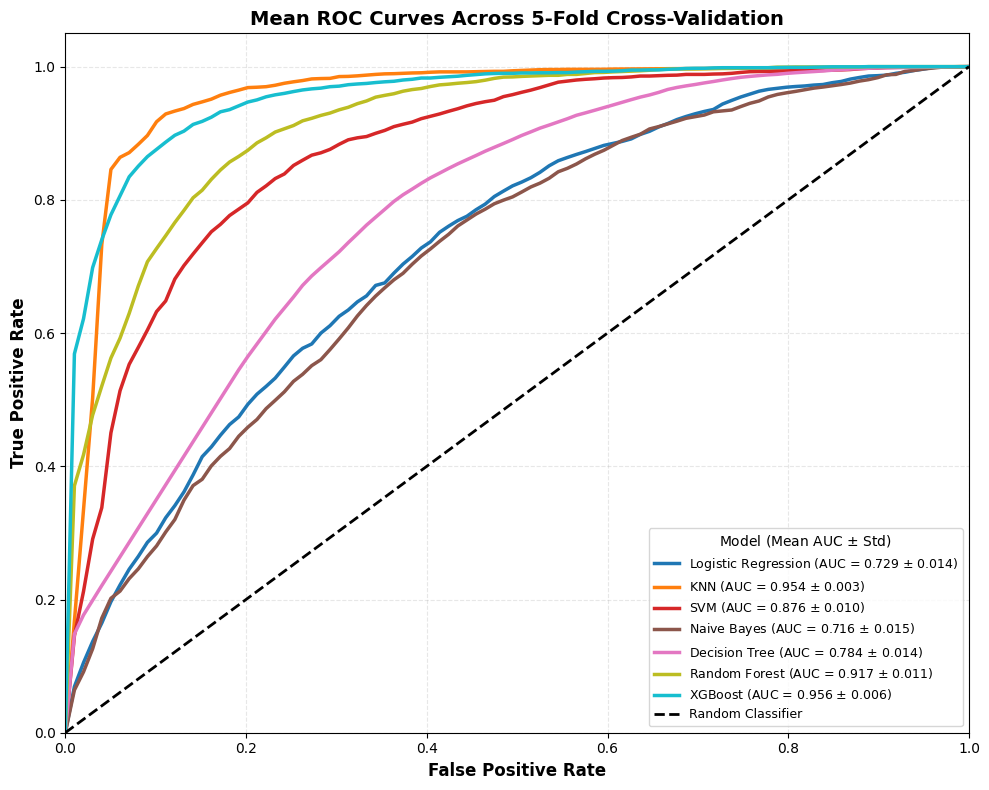


📊 CROSS-VALIDATION ROC-AUC RESULTS (5-FOLD)
              Model  Mean ROC-AUC  Std ROC-AUC
            XGBoost      0.956437     0.005759
                KNN      0.954453     0.002945
      Random Forest      0.917301     0.011425
                SVM      0.876279     0.010308
      Decision Tree      0.783645     0.014403
Logistic Regression      0.728659     0.013706
        Naive Bayes      0.716101     0.015107


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.base import clone

# ============================================================================
# 1. SETUP CROSS-VALIDATION
# ============================================================================
n_splits = 5  # 5-fold CV (Change to 10 for a more rigorous thesis evaluation)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
mean_fpr = np.linspace(0, 1, 100)  # Standardized grid to average ROC curves

# Ensure data is in numpy array format for easy indexing
X = X_train_res.values if hasattr(X_train_res, 'values') else X_train_res
y = y_train_res.values if hasattr(y_train_res, 'values') else y_train_res

# Storage for results
cv_results = []

# ============================================================================
# 2. COMPUTE ROC-AUC ACROSS FOLDS & PLOT
# ============================================================================
plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for (name, model), color in zip(models.items(), colors):
    tprs = []
    aucs = []
    
    # Loop through each fold
    for train_idx, test_idx in cv.split(X, y):
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]
        
        # ✅ CRITICAL: Clone the model so it starts fresh for every fold
        fold_model = clone(model)
        fold_model.fit(X_train_fold, y_train_fold)
        
        try:
            # Get predicted probabilities for the positive class
            y_prob = fold_model.predict_proba(X_test_fold)[:, 1]
            
            # Compute ROC curve and AUC for this specific fold
            fpr, tpr, _ = roc_curve(y_test_fold, y_prob)
            roc_auc_fold = auc(fpr, tpr)
            
            # Interpolate TPR to the common FPR grid (mean_fpr) so we can average them
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)
            aucs.append(roc_auc_fold)
            
        except Exception as e:
            print(f"⚠️ Could not compute ROC for {name}: {e}")
            continue
            
    if len(aucs) > 0:
        # Calculate mean and standard deviation across the folds
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = np.mean(aucs)
        std_auc = np.std(aucs)
        
        # Store for the summary table
        cv_results.append({
            'Model': name,
            'Mean ROC-AUC': mean_auc,
            'Std ROC-AUC': std_auc
        })
        
        # Plot the mean ROC curve for this model
        plt.plot(mean_fpr, mean_tpr, color=color, lw=2.5, 
                 label=f'{name} (AUC = {mean_auc:.3f} $\pm$ {std_auc:.3f})')
        
        # Optional: Uncomment the next 4 lines to add a shaded standard deviation band
        # std_tpr = np.std(tprs, axis=0)
        # tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
        # tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
        # plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=color, alpha=0.15)

# Plot the random classifier diagonal line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='black', label='Random Classifier')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'Mean ROC Curves Across {n_splits}-Fold Cross-Validation', 
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=9, title='Model (Mean AUC $\pm$ Std)')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# ============================================================================
# 3. DISPLAY & SAVE RESULTS TABLE
# ============================================================================
df_cv_results = pd.DataFrame(cv_results).sort_values(by='Mean ROC-AUC', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print(f"📊 CROSS-VALIDATION ROC-AUC RESULTS ({n_splits}-FOLD)")
print("="*80)
print(df_cv_results.to_string(index=False))
print("="*80)

In [47]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

def main():
    print("🔄 1. Loading data...")
    if not os.path.exists('htn_dat.csv'):
        raise FileNotFoundError("❌ 'htn_dat.csv' not found. Please ensure it is in the same directory.")
    
    df = pd.read_csv('htn_dat.csv')

    # Create target variable if it doesn't exist
    if 'hypertension' not in df.columns:
        df['hypertension'] = ((df['SBP'] >= 140) | (df['DBP'] >= 90)).astype(int)

    print("🔄 2. Dropping leakage columns...")
    cols_to_drop = ['ID', 'DBP', 'SBP', 'SBP_ge120', 'IPW_weight', 'hypertension']
    X = df.drop(columns=cols_to_drop)
    y = df['hypertension']

    # Ensure exact feature order
    feature_names = [
        'age', 'BMI', 'married', 'male.gender', 'hgb_centered', 
        'adv_HIV', 'survtime', 'event', 'arv_naive', 'urban.clinic', 'log_creat_centered'
    ]
    X = X[feature_names]

    print("🔄 3. Imputing missing values (SMOTE cannot handle NaNs)...")
    # Impute all missing values with the median before splitting/SMOTE
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)
    X = pd.DataFrame(X_imputed, columns=X.columns)

    print("🔄 4. Setting up preprocessing pipeline...")
    # Since all features are now numeric (int/float), we only need a StandardScaler
    num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_features)
        ])

    print("🔄 5. Splitting data and applying SMOTE...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # SMOTE will now run perfectly because there are no NaNs
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print("🔄 6. Training top 3 models...")
    models = {
        'xgboost': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, eval_metric='logloss', random_state=42))
        ]),
        'random_forest': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42))
        ]),
        'knn': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', KNeighborsClassifier(n_neighbors=7, weights='distance'))
        ])
    }

    for name, model in models.items():
        model.fit(X_train_res, y_train_res)
        joblib.dump(model, f"{name}_model.pkl")
        print(f"  ✅ Saved {name}_model.pkl")

    print("🔄 7. Saving metadata for the Streamlit app...")
    joblib.dump(feature_names, 'feature_names.pkl')
    joblib.dump(imputer, 'imputer.pkl')  # Save the fitted imputer separately
    joblib.dump({'X_test': X_test, 'y_test': y_test}, 'test_data.pkl')
    
    # Optionally save sample data for display in the app
    if len(df) > 0:
        sample_df = df.head(10)
        joblib.dump(sample_df, 'sample_data.pkl')
        print("  ✅ Saved sample_data.pkl")
    
    print("\n🎉 Training complete! All .pkl files saved successfully.")
    print("\n📁 Files created:")
    print("  - xgboost_model.pkl")
    print("  - random_forest_model.pkl")
    print("  - knn_model.pkl")
    print("  - feature_names.pkl")
    print("  - imputer.pkl")
    print("  - test_data.pkl")
    print("  - sample_data.pkl (if data available)")

if __name__ == "__main__":
    main()

🔄 1. Loading data...
🔄 2. Dropping leakage columns...
🔄 3. Imputing missing values (SMOTE cannot handle NaNs)...
🔄 4. Setting up preprocessing pipeline...
🔄 5. Splitting data and applying SMOTE...
🔄 6. Training top 3 models...


  ✅ Saved xgboost_model.pkl


  ✅ Saved random_forest_model.pkl
  ✅ Saved knn_model.pkl
🔄 7. Saving metadata for the Streamlit app...
  ✅ Saved sample_data.pkl

🎉 Training complete! All .pkl files saved successfully.

📁 Files created:
  - xgboost_model.pkl
  - random_forest_model.pkl
  - knn_model.pkl
  - feature_names.pkl
  - imputer.pkl
  - test_data.pkl
  - sample_data.pkl (if data available)
